## 一、Python基本语法 - 选择排序算法

In [3]:
def selection_sort(arr):
    """
    选择排序函数
    参数: arr - 待排序的列表
    返回: 排序后的列表
    """
    n = len(arr)
    # 遍历所有数组元素
    for i in range(n):
        # 找到未排序部分的最小元素
        min_idx = i
        for j in range(i+1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        
        # 将找到的最小元素与未排序部分的第一个元素交换
        arr[i], arr[min_idx] = arr[min_idx], arr[i]
    
    return arr

def test():
    """
    测试函数
    """
    # 测试数据
    test_data = [64, 25, 12, 22, 11, 90, 45, 33]
    
    print("原始数据:", test_data)
    
    # 调用选择排序函数
    sorted_data = selection_sort(test_data.copy())
    
    print("排序后数据:", sorted_data)
    
    return sorted_data

# 执行测试
test()

原始数据: [64, 25, 12, 22, 11, 90, 45, 33]
排序后数据: [11, 12, 22, 25, 33, 45, 64, 90]


[11, 12, 22, 25, 33, 45, 64, 90]

## 二、数据分析 - 使用Pandas分析财富500强数据

In [4]:
import pandas as pd
import numpy as np

# 创建示例数据（财富500强排名数据）
data = {
    'year': [1955, 1955, 1955, 1955, 1955, 1960, 1960, 1960, 1965, 1965],
    'rank': [229, 290, 294, 296, 352, 100, 150, 200, 180, 220],
    'company': ['Norton', 'Schlitz Brewing', 'Pacific Vegetable Oil', 
                'Liebmann Breweries', 'Minneapolis-Moline',
                'Company A', 'Company B', 'Company C', 'Company D', 'Company E'],
    'revenue': [135.0, 100.0, 97.9, 96.0, 77.4, 500.0, 450.0, 400.0, 600.0, 550.0],
    'profit': [np.nan, np.nan, np.nan, np.nan, np.nan, 50.0, 45.0, 40.0, 60.0, 55.0]
}

# 创建DataFrame
df = pd.DataFrame(data)

print("原始数据集:")
print(df)
print("\n" + "="*50)

原始数据集:
   year  rank                company  revenue  profit
0  1955   229                 Norton    135.0     NaN
1  1955   290        Schlitz Brewing    100.0     NaN
2  1955   294  Pacific Vegetable Oil     97.9     NaN
3  1955   296     Liebmann Breweries     96.0     NaN
4  1955   352     Minneapolis-Moline     77.4     NaN
5  1960   100              Company A    500.0    50.0
6  1960   150              Company B    450.0    45.0
7  1960   200              Company C    400.0    40.0
8  1965   180              Company D    600.0    60.0
9  1965   220              Company E    550.0    55.0



In [5]:
# 1. 数据显示
print("数据前5行:")
print(df.head())
print("\n数据基本信息:")
print(df.info())

数据前5行:
   year  rank                company  revenue  profit
0  1955   229                 Norton    135.0     NaN
1  1955   290        Schlitz Brewing    100.0     NaN
2  1955   294  Pacific Vegetable Oil     97.9     NaN
3  1955   296     Liebmann Breweries     96.0     NaN
4  1955   352     Minneapolis-Moline     77.4     NaN

数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     10 non-null     int64  
 1   rank     10 non-null     int64  
 2   company  10 non-null     object 
 3   revenue  10 non-null     float64
 4   profit   5 non-null      float64
dtypes: float64(2), int64(2), object(1)
memory usage: 532.0+ bytes
None


In [6]:
# 2. 检查数据列属性
print("列名:", df.columns.tolist())
print("\n数据类型:")
print(df.dtypes)
print("\n数据统计信息:")
print(df.describe())

列名: ['year', 'rank', 'company', 'revenue', 'profit']

数据类型:
year         int64
rank         int64
company     object
revenue    float64
profit     float64
dtype: object

数据统计信息:
              year        rank     revenue     profit
count    10.000000   10.000000   10.000000   5.000000
mean   1958.500000  231.100000  300.630000  50.000000
std       4.116363   77.262108  217.110366   7.905694
min    1955.000000  100.000000   77.400000  40.000000
25%    1955.000000  185.000000   98.425000  45.000000
50%    1957.500000  224.500000  267.500000  50.000000
75%    1960.000000  293.000000  487.500000  55.000000
max    1965.000000  352.000000  600.000000  60.000000


In [7]:
# 3. 数据过滤 - 删除"profit"列包含异常值(NaN)的数据行
print("删除profit列异常值前的数据行数:", len(df))

# 删除profit列为NaN的行
df_cleaned = df.dropna(subset=['profit'])

print("删除profit列异常值后的数据行数:", len(df_cleaned))
print("\n清洗后的数据:")
print(df_cleaned)

删除profit列异常值前的数据行数: 10
删除profit列异常值后的数据行数: 5

清洗后的数据:
   year  rank    company  revenue  profit
5  1960   100  Company A    500.0    50.0
6  1960   150  Company B    450.0    45.0
7  1960   200  Company C    400.0    40.0
8  1965   180  Company D    600.0    60.0
9  1965   220  Company E    550.0    55.0


In [8]:
# 4. 属性查询 - 按年份分组统计
print("按年份统计平均收入和利润:")
yearly_stats = df_cleaned.groupby('year')[['revenue', 'profit']].mean()
print(yearly_stats)

按年份统计平均收入和利润:
      revenue  profit
year                 
1960    450.0    45.0
1965    575.0    57.5


## 三、数据图形绘制 - 使用Matplotlib

In [9]:
import matplotlib.pyplot as plt
import matplotlib

# 设置中文字体（避免中文显示为方框）
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# 准备数据 - 按年份统计平均利润和收入
yearly_data = df_cleaned.groupby('year')[['revenue', 'profit']].mean().reset_index()

print("用于绘图的数据:")
print(yearly_data)

用于绘图的数据:
   year  revenue  profit
0  1960    450.0    45.0
1  1965    575.0    57.5


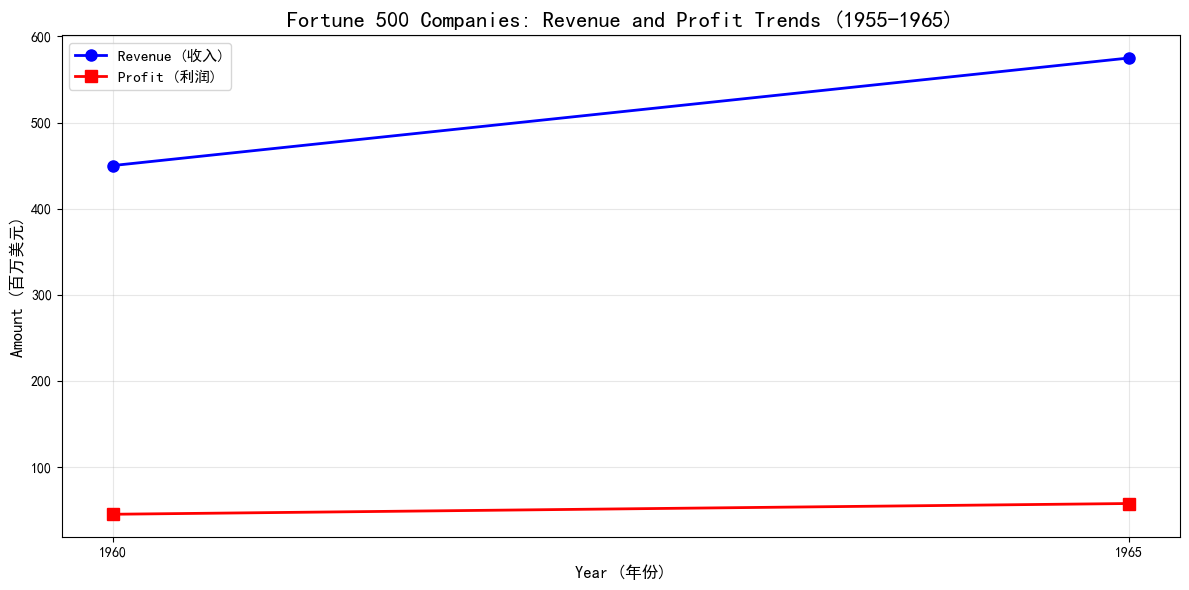

✓ 图表绘制完成！


In [10]:
# 绘制一张图同时显示利润和收入
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制收入折线图
ax.plot(yearly_data['year'], yearly_data['revenue'], 
        marker='o', linewidth=2, markersize=8, 
        label='Revenue (收入)', color='blue')

# 绘制利润折线图
ax.plot(yearly_data['year'], yearly_data['profit'], 
        marker='s', linewidth=2, markersize=8, 
        label='Profit (利润)', color='red')

# 设置标题和标签
ax.set_title('Fortune 500 Companies: Revenue and Profit Trends (1955-1965)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Year (年份)', fontsize=12)
ax.set_ylabel('Amount (百万美元)', fontsize=12)

# 添加网格
ax.grid(True, alpha=0.3)

# 添加图例
ax.legend(fontsize=11, loc='best')

# 设置x轴刻度
ax.set_xticks(yearly_data['year'])

# 调整布局并显示
plt.tight_layout()
plt.show()

print("✓ 图表绘制完成！")

## 四、进阶可视化 - 添加统计信息

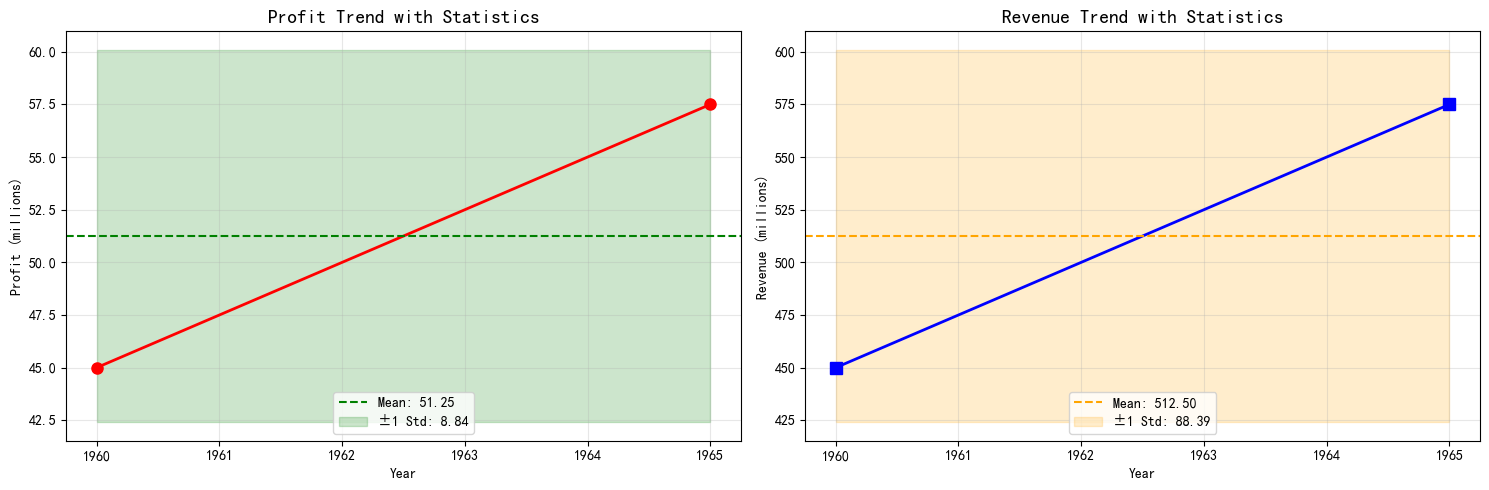

✓ 进阶图表绘制完成！


In [11]:
# 绘制包含均值和标准差的图表
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：利润趋势
mean_profit = yearly_data['profit'].mean()
std_profit = yearly_data['profit'].std()

axes[0].plot(yearly_data['year'], yearly_data['profit'], 
             marker='o', linewidth=2, markersize=8, color='red')
axes[0].axhline(y=mean_profit, color='green', linestyle='--', 
                label=f'Mean: {mean_profit:.2f}')
axes[0].fill_between(yearly_data['year'], 
                     mean_profit - std_profit, 
                     mean_profit + std_profit,
                     alpha=0.2, color='green',
                     label=f'±1 Std: {std_profit:.2f}')
axes[0].set_title('Profit Trend with Statistics', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Profit (millions)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：收入趋势
mean_revenue = yearly_data['revenue'].mean()
std_revenue = yearly_data['revenue'].std()

axes[1].plot(yearly_data['year'], yearly_data['revenue'], 
             marker='s', linewidth=2, markersize=8, color='blue')
axes[1].axhline(y=mean_revenue, color='orange', linestyle='--', 
                label=f'Mean: {mean_revenue:.2f}')
axes[1].fill_between(yearly_data['year'], 
                     mean_revenue - std_revenue, 
                     mean_revenue + std_revenue,
                     alpha=0.2, color='orange',
                     label=f'±1 Std: {std_revenue:.2f}')
axes[1].set_title('Revenue Trend with Statistics', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Revenue (millions)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ 进阶图表绘制完成！")